# Excercise 2a: Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
X_train = pd.read_csv("ex2_train.csv")
y_train = pd.read_csv("ex2_class_train.csv")
data = X_train.copy()
data['Survived'] = y_train

In [6]:
data.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,1,"Partner, Mr. Austen",male,45.5,0,0,28.5000,S,0
1,2,"Berriman, Mr. William John",male,23.0,0,0,13.0000,S,0
2,3,"Tikkanen, Mr. Juho",male,32.0,0,0,7.9250,S,0
3,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,7.8542,S,0
4,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,31.2750,S,0


This is a widely used dataset that contains information on the passengers who were aboard the Titanic when it sank on its maiden voyage in 1912. We will use it for a supervised learning exercise (ex2b) to predict whether a passenger can survive based on his or her attributes. Before constructing the classifier, you need to do some guided exploratory data analysis in ex2a.

The column meanings are: 
* Survived: Survival status (0 = No, 1 = Yes).
* Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd).
* Name: Name of the passenger.
* Sex: Gender of the passenger (male/female).
* Age: Age of the passenger in years.
* SibSp: Number of siblings/spouses aboard the Titanic.
* Parch: Number of parents/children aboard the Titanic.
* Fare: Passenger fare.
* Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

**TODO: Please answer the following questions by using suitable analysis tools, e.g. statistics or visualizations.** To pass the exercise, you need to correctly answer three or more of Questions 1 to 5. A correct answer includes a correct statement and the analysis result that support the statement.

# Example Question: Is gender related to survival rate?

Answer: Yes, females had a higher survival rate.

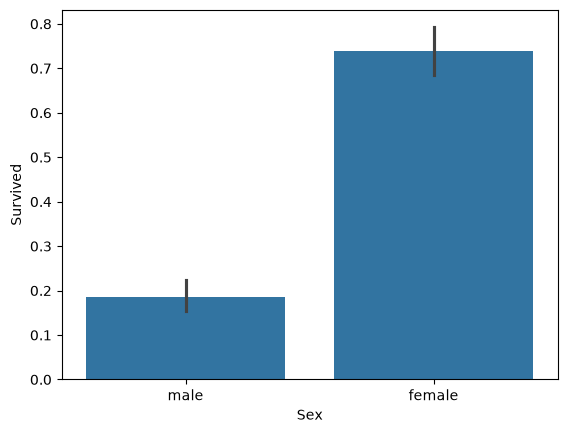

In [7]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Sex', y='Survived', data=data)
plt.show()

# Question 1: Did first-class passengers survive more?

Answer: Yes, the barplot shows that the 1st class has a higher survival rate of around 0.6, followed by 2nd class at around 0.5 and 3rd class at around 0.25.


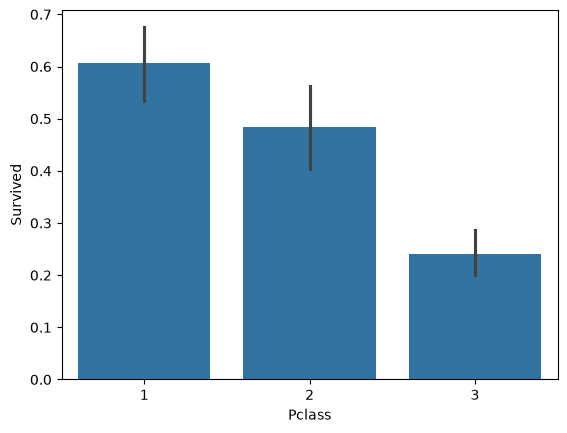

In [28]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Pclass', y='Survived', data=data)
plt.show()

# Question 2: Is survival related to Embarked?

Answer: It seems that the Embarked category C has a higher survival rate than S and Q, suggesting that survival might be related to Embarked.

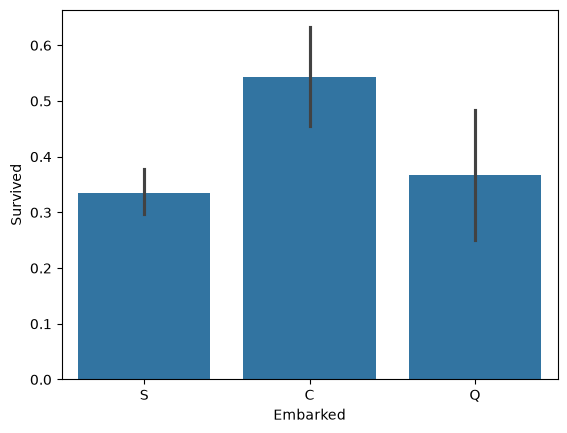

In [17]:
sns.barplot(x='Embarked', y='Survived', data=data)
plt.show()

# Question 3: How is age related to survival?

Answer: The visualisation suggests that the survival is related to age, where the younger passengers seemed to have survived more than the older passengers.

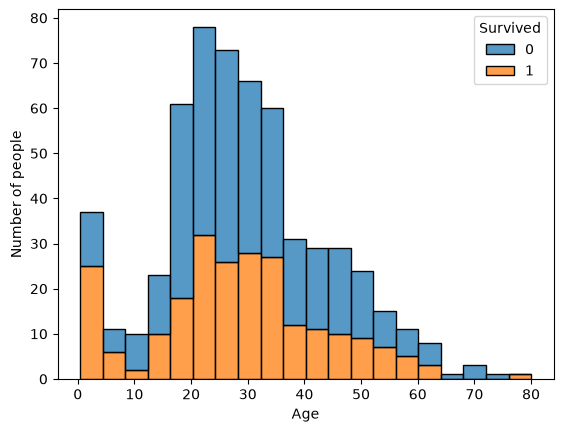

In [31]:
sns.histplot(
    data=data,
    x='Age',
    hue='Survived',
    bins=20,
    multiple='stack'
)
plt.xlabel('Age')
plt.ylabel('Number of people')
plt.show()


# Question 4: Does family size somehow affect the survival rate?

Answer: It seems that the family sizes of 2 - 4 appear to have a higher survival rate, suggesting that family size might affect the survival rate.

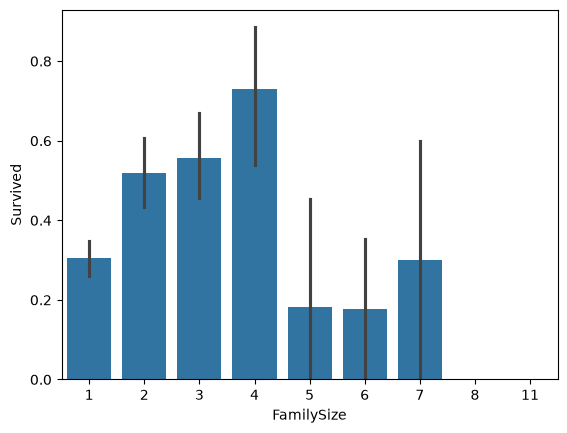

,mean,count
FamilySize,,
1,0.305361,429
2,0.519685,127
3,0.556962,79
4,0.730769,26
5,0.181818,11
6,0.176471,17
7,0.300000,10
8,0.000000,6
11,0.000000,7


In [36]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
sns.barplot(x='FamilySize', y='Survived', data=data)
plt.show()

data.groupby('FamilySize')['Survived'].agg(['mean', 'count'])

# Question 5: Some passengers with certain titles seemed to have more chance to survive. Is that true?

Answer: Yes, there appears to be a relationship between passenger title and survival. The common titles show clear differences: Mr had a much lower survival rate (~16%) than Miss (~67%), Mrs (~83%) and Master (~55%). However, title is closely related to gender and passenger class, which also show strong relationships with survival. Therefore, the observed relationship between title and survival may partly be explained by these factors rather than the title itself. The rare titles have very few observations, so their survival rates are unreliable.

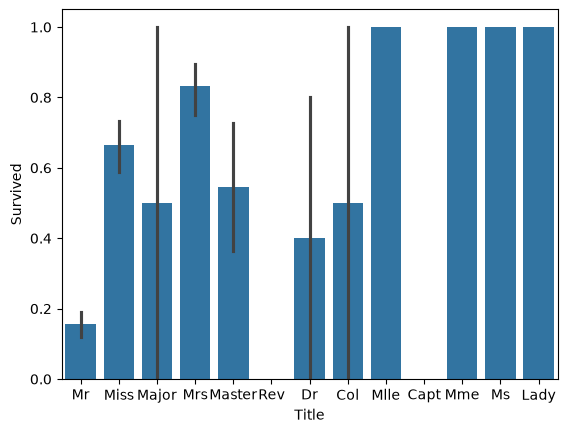

Title
Mr        419
Miss      143
Mrs        96
Master     33
Rev         5
Dr          5
Major       2
Col         2
Mlle        2
Capt        1
Mme         1
Ms          1
Lady        1
Name: count, dtype: int64

In [39]:
data['Title'] = data['Name'].str.extract(r',\s*([A-Za-z]+)\.')

data.groupby('Title')['Survived'].agg(['mean', 'count']).sort_values('count', ascending=False)

sns.barplot(x='Title', y='Survived', data=data)
plt.show()

data['Title'].value_counts()